# 0. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


# 1. Import data

In [4]:
taxi_jan2019 = pd.read_parquet("data/yellow_tripdata_2019-01.parquet")
taxi_jan2019.head(2)
taxi_jan2019.shape
taxi_data = pd.concat([taxi_jan2019])
print(taxi_data.shape)
taxi_data.head()


(7696617, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,1.5,1.0,N,151,239,1,7.0,0.5,0.5,1.65,0.0,0.3,9.95,NaN,None
1,1,2019-01-01 00:59:47,2019-01-01 01:18:59,1.0,2.6,1.0,N,239,246,1,14.0,0.5,0.5,1.00,0.0,0.3,16.30,NaN,None
2,2,2018-12-21 13:48:30,2018-12-21 13:52:40,3.0,0.0,1.0,N,236,236,1,4.5,0.5,0.5,0.00,0.0,0.3,5.80,NaN,None
3,2,2018-11-28 15:52:25,2018-11-28 15:55:45,5.0,0.0,1.0,N,193,193,2,3.5,0.5,0.5,0.00,0.0,0.3,7.55,NaN,None
4,2,2018-11-28 15:56:57,2018-11-28 15:58:33,5.0,0.0,2.0,N,193,193,2,52.0,0.0,0.5,0.00,0.0,0.3,55.55,NaN,None


# 2. Data exploration

In [6]:
taxi_data.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='object')

In [7]:
taxi_data = taxi_data[['tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID',
       'PULocationID', 'DOLocationID', 'payment_type', 
       'total_amount']]

In [8]:
taxi_data.shape

(7696617, 9)

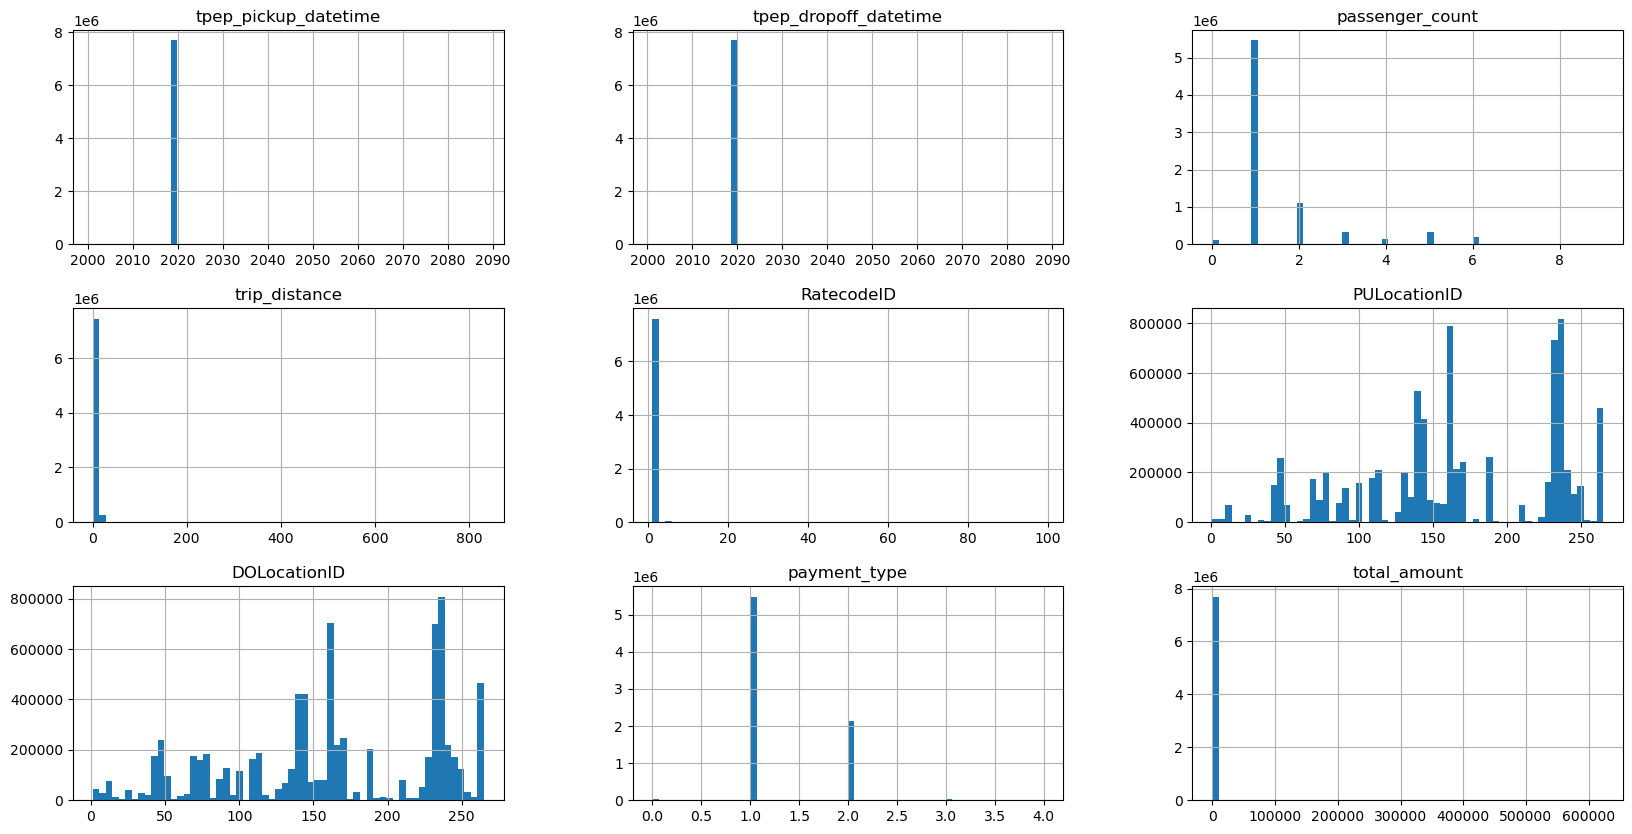

In [9]:
taxi_data.hist(figsize=(20,10), bins=60)
plt.show()

In [10]:
taxi_data["RatecodeID"].value_counts()

RatecodeID
1.0     7430288
2.0      166093
5.0       54570
3.0       11801
4.0        4895
99.0        252
6.0          46
Name: count, dtype: int64

In [11]:
taxi_data["total_amount"].value_counts()

total_amount
7.30      170471
7.80      167914
6.80      167879
8.30      161705
8.80      159067
           ...  
196.32         1
0.56           1
167.11         1
302.30         1
76.89          1
Name: count, Length: 12193, dtype: int64

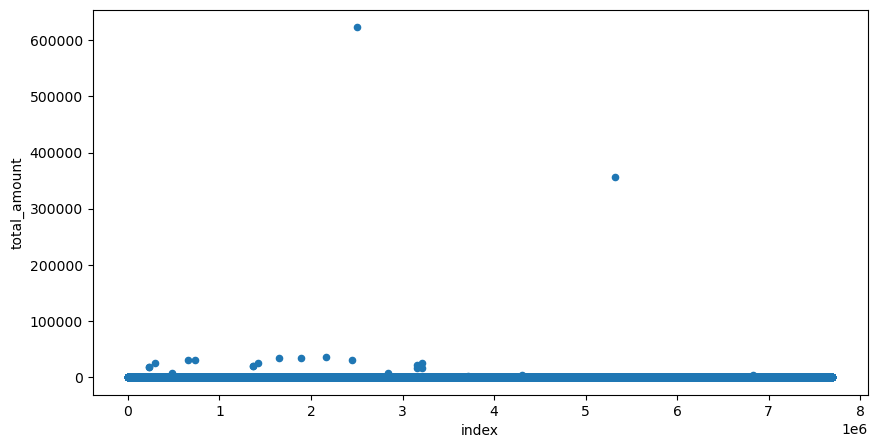

In [12]:
taxi_data.reset_index().plot(kind="scatter", y = "total_amount", x = "index", figsize=(10,5))
plt.show()

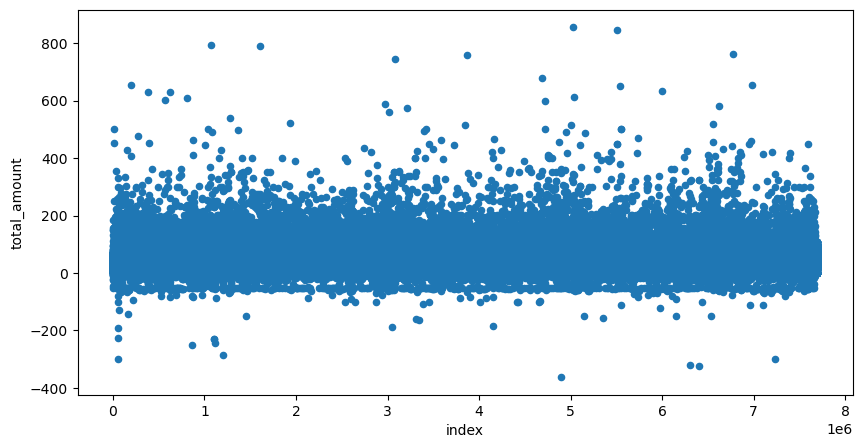

In [13]:
taxi_data[taxi_data["total_amount"] < 1000].reset_index().plot(kind = "scatter", y = "total_amount", x = "index", figsize=(10,5))
plt.show()

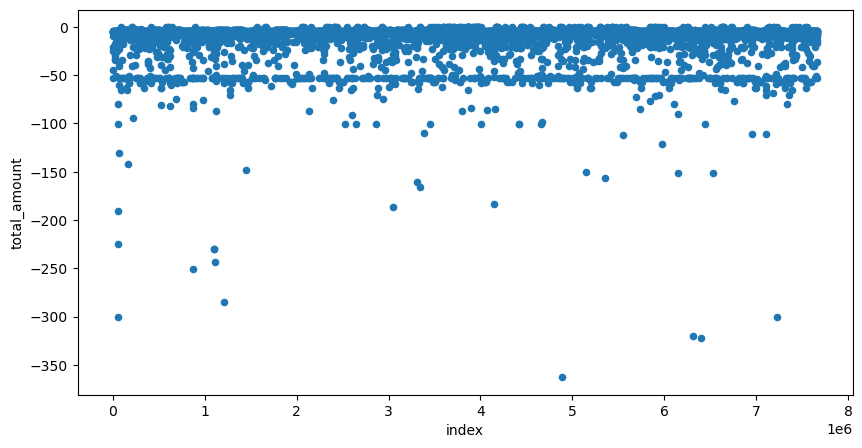

In [14]:
taxi_data[taxi_data["total_amount"]<0].reset_index().plot(kind="scatter", y="total_amount", x="index",  figsize=(10,5))
plt.show()

In [15]:
taxi_data[taxi_data["total_amount"]<0].head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount
663,2019-01-01 00:32:56,2019-01-01 00:33:35,2.0,0.10,1.0,148,148,3,-3.8
2402,2019-01-01 00:14:18,2019-01-01 00:40:55,1.0,4.13,1.0,170,238,4,-20.3
2541,2019-01-01 00:31:27,2019-01-01 00:42:39,1.0,1.35,1.0,162,234,4,-9.8
2544,2019-01-01 00:45:57,2019-01-01 00:46:07,1.0,0.00,1.0,234,234,4,-3.8
2547,2019-01-01 00:48:35,2019-01-01 00:49:59,1.0,0.16,1.0,234,234,4,-4.3


In [16]:
taxi_data[taxi_data["total_amount"]<0]["payment_type"].value_counts()

payment_type
3    4083
4    2667
2     376
1       1
Name: count, dtype: int64

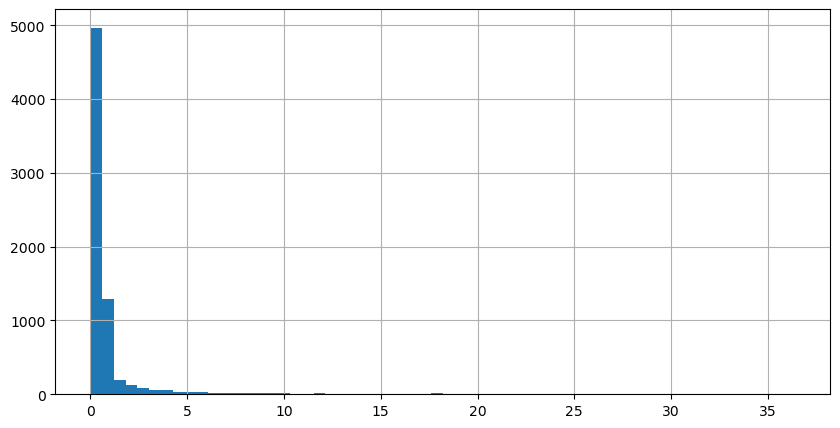

In [17]:
#taxi_data[taxi_data["total_amount"]<0]["trip_distance"].hist(bins=60,figsize=(10,5))
#df = taxi_data[(taxi_data["total_amount"]<0) & (taxi_data["trip_distance"]<1)]
#df.hist(bins = 60, figsize=(10,10))

taxi_data[taxi_data["total_amount"]<0]["trip_distance"].hist(bins=60, figsize=(10,5))

plt.show()



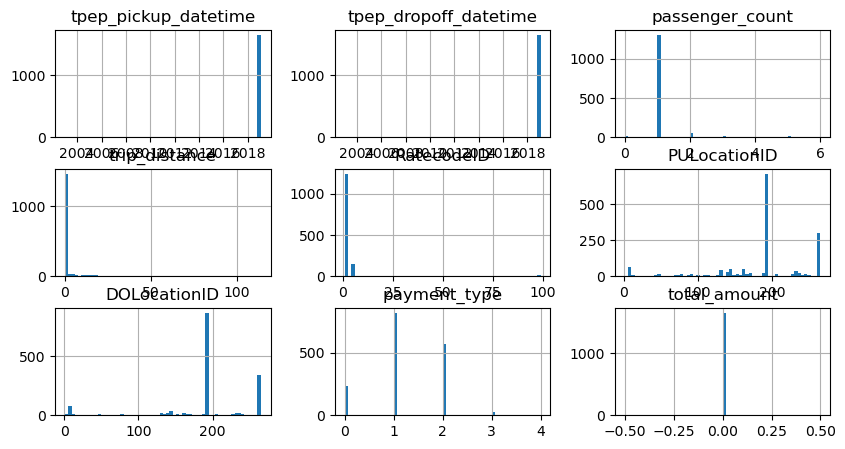

(1643, 9)

In [18]:
taxi_data[taxi_data["total_amount"] == 0].hist(bins=60, figsize=(10,5))
plt.show()
taxi_data[taxi_data["total_amount"] == 0].shape

In [19]:
taxi_data[taxi_data["total_amount"] == 0]["trip_distance"].value_counts()


trip_distance
0.00     1323
0.03        9
0.01        8
0.06        6
1.00        4
         ... 
11.86       1
4.59        1
20.92       1
18.37       1
12.30       1
Name: count, Length: 256, dtype: int64

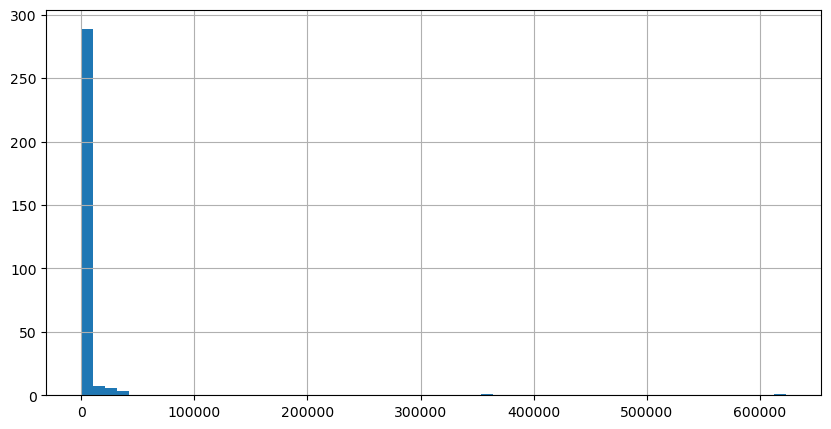

In [20]:
taxi_data[taxi_data["total_amount"]>300]["total_amount"].hist(bins=60, figsize=(10,5))
plt.show()

In [21]:
taxi_data[taxi_data["total_amount"]<100]["total_amount"].mean()
taxi_data["total_amount"].mean()

15.810651344610214

# 3. Data cleaning

In [23]:
taxi_data_filtered = taxi_data[(taxi_data["total_amount"]>0) & (taxi_data["total_amount"]<200)].dropna()
taxi_data_filtered.shape

(7658235, 9)

In [24]:

taxi_data_filtered.isna().sum()


tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
PULocationID             0
DOLocationID             0
payment_type             0
total_amount             0
dtype: int64

# 4. Data preparation

In [26]:
taxi_data_prepared = taxi_data_filtered.copy()

In [27]:
taxi_data_prepared.dtypes

tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
total_amount                    float64
dtype: object

In [28]:
taxi_data_prepared.loc[:,"tpep_pickup_datetime"]=pd.to_datetime(taxi_data_prepared.loc[:,"tpep_pickup_datetime"])
taxi_data_prepared.loc[:,"tpep_dropoff_datetime"]=pd.to_datetime(taxi_data_prepared.loc[:,"tpep_dropoff_datetime"])

In [29]:
taxi_data_prepared["passenger_count"] = taxi_data_prepared["passenger_count"].astype(int)
taxi_data_prepared["RatecodeID"] = taxi_data_prepared["RatecodeID"].fillna(0).astype(int).astype(str)
taxi_data_prepared["PULocationID"] = taxi_data_prepared["RatecodeID"].astype(str)
taxi_data_prepared["DOLocationID"] = taxi_data_prepared["DOLocationID"].astype(str)
taxi_data_prepared["payment_type"] = taxi_data_prepared.loc[:,"payment_type"].astype(str)


taxi_data_prepared.dtypes

tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                   int64
trip_distance                   float64
RatecodeID                       object
PULocationID                     object
DOLocationID                     object
payment_type                     object
total_amount                    float64
dtype: object

Transforming variables into the formats we need them

In [31]:
taxi_data_prepared["transaction_date"] = pd.to_datetime(taxi_data_prepared["tpep_pickup_datetime"].dt.date)

taxi_data_prepared["transaction_year"] = taxi_data_prepared["tpep_pickup_datetime"].dt.year
taxi_data_prepared["transaction_month"] = taxi_data_prepared["tpep_pickup_datetime"].dt.month
taxi_data_prepared["transaction_day"] = taxi_data_prepared["tpep_pickup_datetime"].dt.day
taxi_data_prepared["transaction_hour"] = taxi_data_prepared["tpep_pickup_datetime"].dt.hour

taxi_data_prepared.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount,transaction_date,transaction_year,transaction_month,transaction_day,transaction_hour
0,2019-01-01 00:46:40,2019-01-01 00:53:20,1,1.5,1,1,239,1,9.95,2019-01-01,2019,1,1,0
1,2019-01-01 00:59:47,2019-01-01 01:18:59,1,2.6,1,1,246,1,16.30,2019-01-01,2019,1,1,0
2,2018-12-21 13:48:30,2018-12-21 13:52:40,3,0.0,1,1,236,1,5.80,2018-12-21,2018,12,21,13
3,2018-11-28 15:52:25,2018-11-28 15:55:45,5,0.0,1,1,193,2,7.55,2018-11-28,2018,11,28,15
4,2018-11-28 15:56:57,2018-11-28 15:58:33,5,0.0,2,2,193,2,55.55,2018-11-28,2018,11,28,15


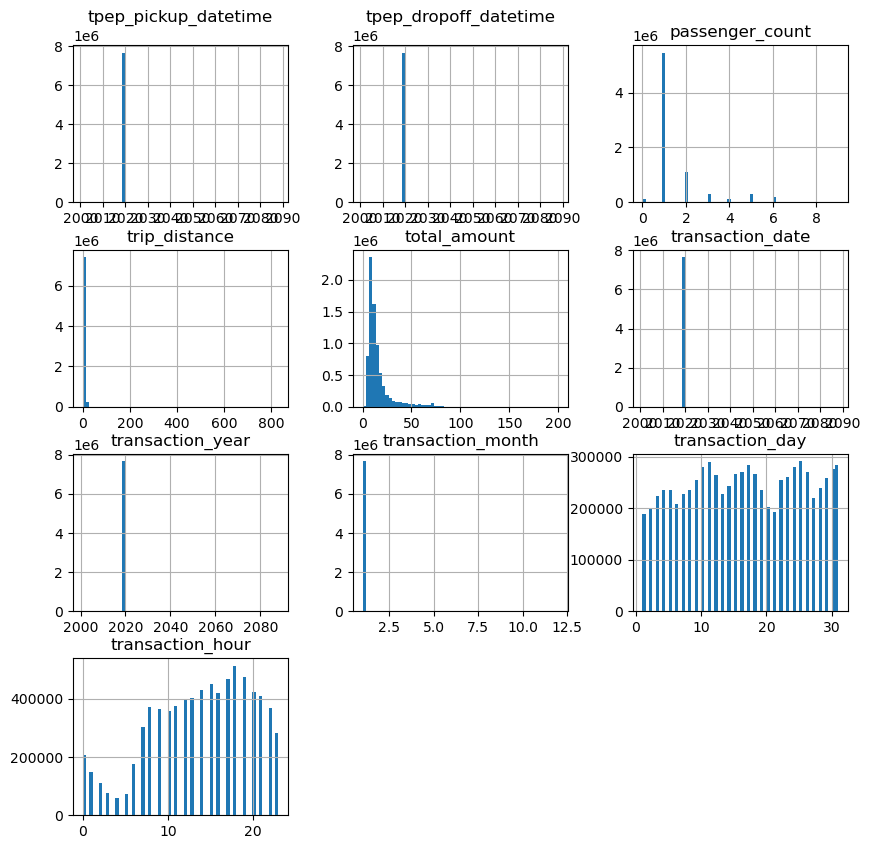

In [32]:
taxi_data_prepared.hist(bins=60, figsize=(10,10))
plt.show()

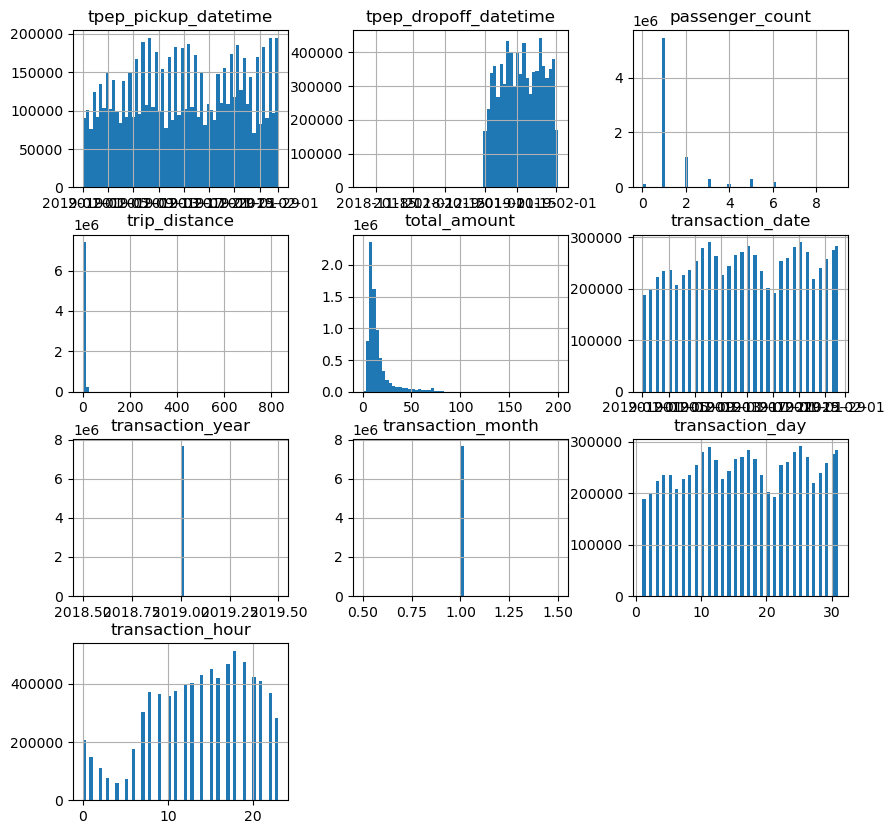

(7657703, 14)

In [129]:
taxi_data_prepared = taxi_data_prepared[taxi_data_prepared["transaction_month"] == 1]
taxi_data_prepared = taxi_data_prepared[taxi_data_prepared["transaction_year"] == 2019]
taxi_data_prepared.hist(bins=60, figsize=(10,10))


Noting down categorical and numerical columns

In [35]:
taxi_data_prepared.columns


Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count',
       'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID',
       'payment_type', 'total_amount', 'transaction_date', 'transaction_year',
       'transaction_month', 'transaction_day', 'transaction_hour'],
      dtype='object')

In [36]:
categorical_columns = [ 'PULocationID', 'transaction_date', 'transaction_year','transaction_month', 'transaction_day', 'transaction_hour']
numerical_columns = ['trip_distance','total_amount']
all_needed_columns = categorical_columns + numerical_columns

(7657703, 8)


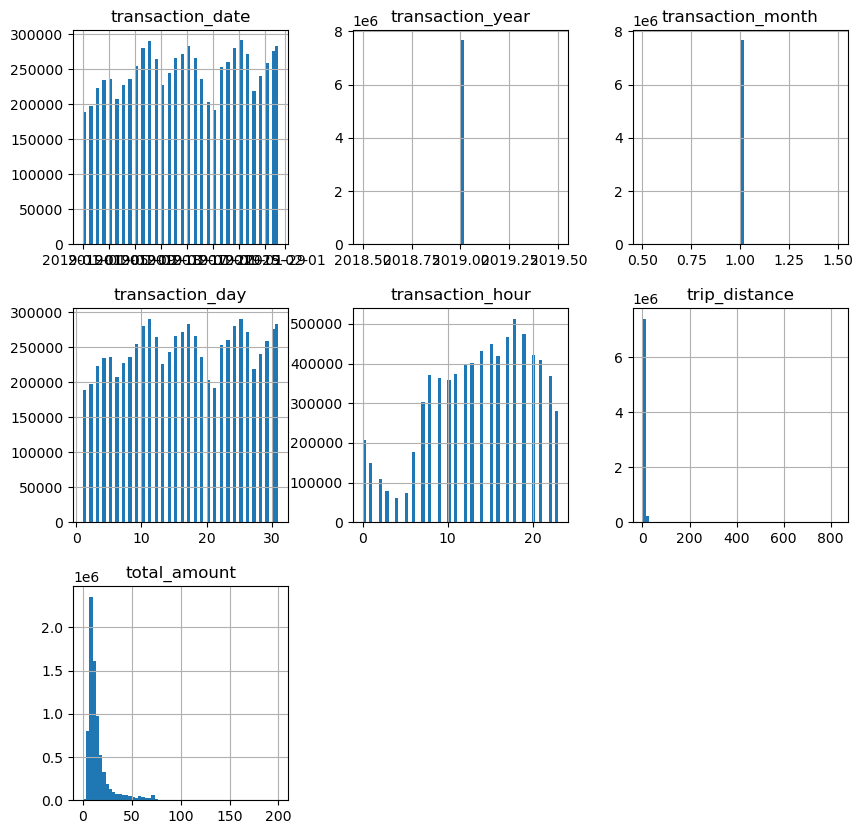

In [133]:
main_taxi_df = taxi_data_prepared[all_needed_columns]
print(main_taxi_df.shape)
main_taxi_df.head(100)



Aggregate data points
Now is a good time to think about what we want to predict. Depending on this, we need to transform the data.

(3856, 9)


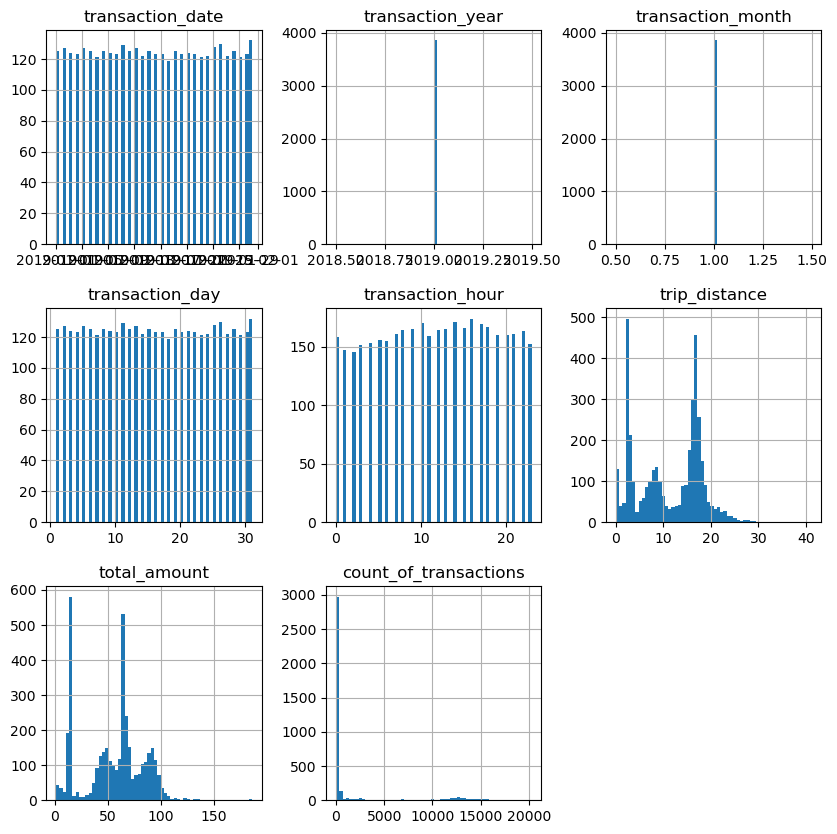

In [135]:
taxi_grouped_by_region = main_taxi_df.groupby(categorical_columns).mean().reset_index()
taxi_grouped_by_region['count_of_transactions'] = main_taxi_df.groupby(categorical_columns).count().reset_index()['trip_distance']
print(taxi_grouped_by_region.shape)
taxi_grouped_by_region.head()

taxi_grouped_by_region.hist(bins=60, figsize=(10,10))
plt.show()


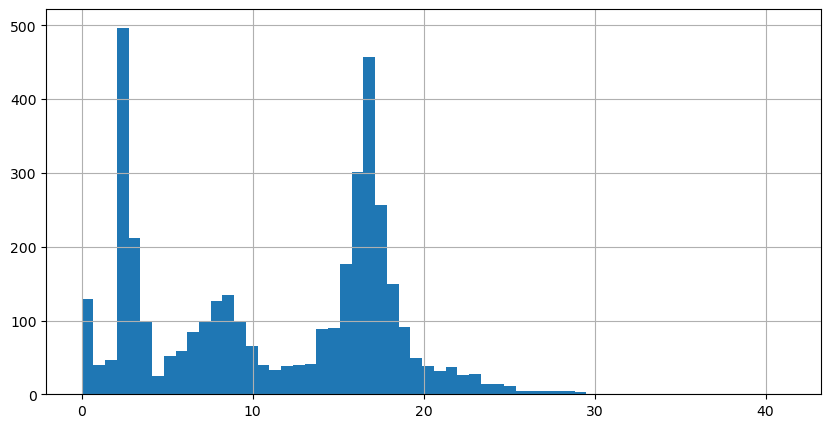

In [40]:
taxi_grouped_by_region["trip_distance"].hist(bins=60, figsize = (10,5))
plt.show()

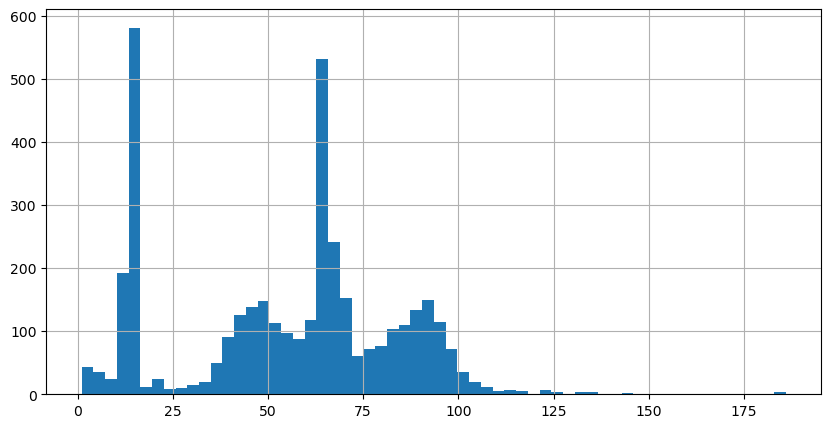

In [41]:
taxi_grouped_by_region["total_amount"].hist(bins=60, figsize = (10,5))
plt.show()

# 5. Benchmark model

In [78]:
data_for_benchmark_model = taxi_grouped_by_region.copy()

In [141]:
data_for_benchmark_model["transaction_month"] = data_for_benchmark_model.loc[:,"transaction_month"].astype(int)
data_for_benchmark_model["transaction_day"] = data_for_benchmark_model.loc[:,"transaction_day"].astype(int)
data_for_benchmark_model["transaction_hour"] = data_for_benchmark_model.loc[:,"transaction_hour"].astype(int)
categorical_features_benchmark = ['PULocationID','transaction_month','transaction_day','transaction_hour']
input_features_benchmark  = categorical_features_benchmark + ['trip_distance']
target_feature_benchmark  = 'total_amount'


## 5.1 Train-test split

In [150]:
from sklearn.model_selection import train_test_split
X_bench = data_for_benchmark_model[input_features_benchmark]
y_bench = data_for_benchmark_model[target_feature_benchmark]

#one-hot encode
X_bench = pd.get_dummies(x_bench)


X_train_b,X_test_b,y_train_b,y_test_b = train_test_split(X_bench, y_bench, test_size=0.33, random_state=42)



## 5.2 Fit a model to the data

In [152]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=10)

tree.fit(X_train_b, y_train_b)

DecisionTreeRegressor(max_depth=10)

# 5.3 Model evaluation

In [155]:


model_at_hand = tree

y_pred_b = model_at_hand.predict(X_test_b)

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from math import sqrt

print('mean_absolute_error', mean_absolute_error(y_test_b, y_pred_b))
print('mean_squared_error', mean_squared_error(y_test_b, y_pred_b))
print('root_mean_squared_error', sqrt(mean_squared_error(y_test_b, y_pred_b)))
print('r2', r2_score(y_test_b, y_pred_b))



mean_absolute_error 4.393129658018555
mean_squared_error 92.45464721594664
root_mean_squared_error 9.615333962788117
r2 0.8874337712427174


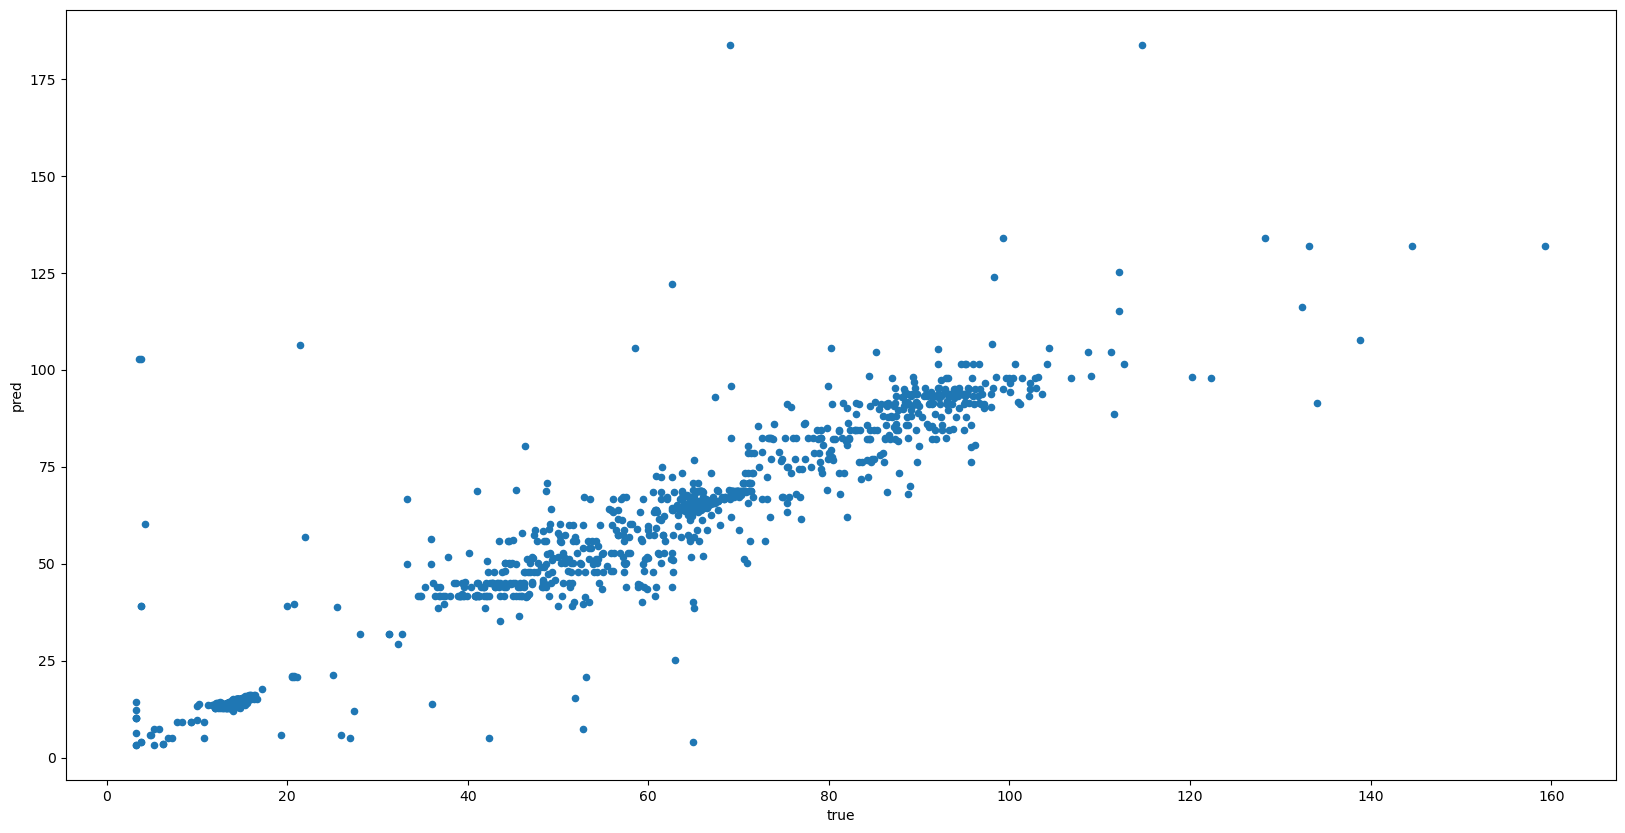

In [165]:
data = {'true': y_test_b, 'pred': y_pred_b}
results = pd.DataFrame(data)
results.plot(figsize=(20,10), kind='scatter', x='true', y='pred')
plt.show()

## 5.4 Fix Problems

In [168]:
categorical_features_benchmark = ['PULocationID','transaction_month','transaction_day','transaction_hour']
input_features_benchmark  = categorical_features_benchmark 
target_feature_benchmark  = 'total_amount'

from sklearn.model_selection import train_test_split
X_bench = data_for_benchmark_model[input_features_benchmark]
y_bench = data_for_benchmark_model[target_feature_benchmark]

X_bench = pd.get_dummies(X_bench)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bench, y_bench, test_size = 0.33, random_state=42)

from sklearn.tree import DecisionTreeRegressor
tree = DecisionTreeRegressor(max_depth=10)
tree.fit(X_train_b,y_train_b)

model_at_hand = tree
y_pred_b = model_at_hand.predict(X_test_b)

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from math import sqrt

print('mean_absolute_error', mean_absolute_error(y_test_b, y_pred_b))
print('mean_squared_error', mean_squared_error(y_test_b, y_pred_b))
print('root_mean_squared_error', sqrt(mean_squared_error(y_test_b, y_pred_b)))
print('r2', r2_score(y_test_b, y_pred_b))





mean_absolute_error 7.42398835771994
mean_squared_error 261.47111204041056
root_mean_squared_error 16.170068399373285
r2 0.6816512971747588


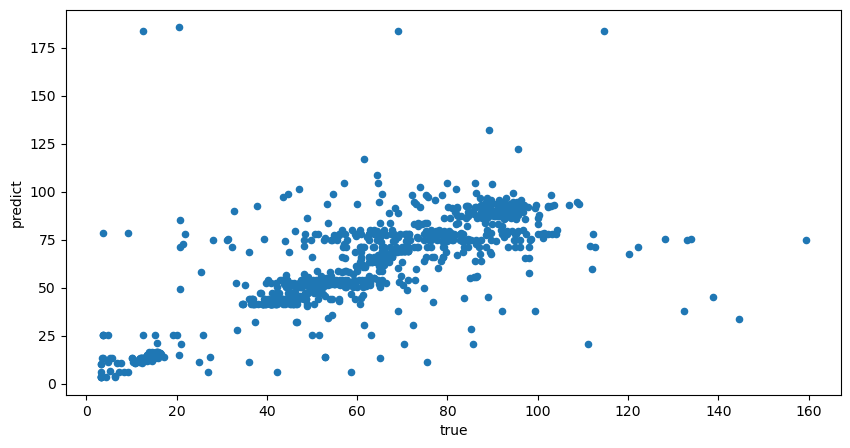

In [182]:

data = {"true":y_test_b, "predict": y_pred_b}
results = pd.DataFrame(data)
results.plot(x="true", y = "predict", kind = "scatter",figsize = (10,5))
plt.show()

# 6. Feature engineering

In [185]:
taxi_grouped_by_region.head()

,PULocationID,transaction_date,transaction_year,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions
0,1,2019-01-01,2019,1,1,0,2.810215,15.501245,13256
1,1,2019-01-01,2019,1,1,1,3.008797,15.880940,15258
2,1,2019-01-01,2019,1,1,2,3.125909,15.789893,13035
3,1,2019-01-01,2019,1,1,3,3.203513,15.493270,10292
4,1,2019-01-01,2019,1,1,4,3.535103,16.105968,6686


In [201]:

data_with_new_features = taxi_grouped_by_region.copy()
data_with_new_features["transaction_week_day"] = data_with_new_features["transaction_date"].dt.weekday
data_with_new_features['weekend'] = data_with_new_features['transaction_week_day'].apply(lambda x: True if x == 5 or x == 6 else False)


In [207]:
from pandas.tseries.holiday import USFederalHolidayCalendar

cal = USFederalHolidayCalendar()
holidays = cal.holidays(start='2018',
                        end='2020').date

data_with_new_features['is_holiday'] = data_with_new_features['transaction_date'].dt.date.isin(holidays)

data_with_new_features.head()

,PULocationID,transaction_date,transaction_year,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday
0,1,2019-01-01,2019,1,1,0,2.810215,15.501245,13256,1,False,True
1,1,2019-01-01,2019,1,1,1,3.008797,15.880940,15258,1,False,True
2,1,2019-01-01,2019,1,1,2,3.125909,15.789893,13035,1,False,True
3,1,2019-01-01,2019,1,1,3,3.203513,15.493270,10292,1,False,True
4,1,2019-01-01,2019,1,1,4,3.535103,16.105968,6686,1,False,True


In [211]:
zone_lookup = pd.read_csv('data/taxi_zone_lookup.csv')
zone_lookup = zone_lookup[['LocationID','Borough']]
zone_lookup['LocationID'] = zone_lookup['LocationID'].astype(str)
zone_lookup.head()

,LocationID,Borough
0,1,EWR
1,2,Queens
2,3,Bronx
3,4,Manhattan
4,5,Staten Island


In [213]:
data_with_new_features = data_with_new_features.merge(zone_lookup, left_on='PULocationID', right_on='LocationID', how='left')
data_with_new_features.drop('LocationID', axis=1, inplace=True)
data_with_new_features.head()

,PULocationID,transaction_date,transaction_year,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday,Borough
0,1,2019-01-01,2019,1,1,0,2.810215,15.501245,13256,1,False,True,EWR
1,1,2019-01-01,2019,1,1,1,3.008797,15.880940,15258,1,False,True,EWR
2,1,2019-01-01,2019,1,1,2,3.125909,15.789893,13035,1,False,True,EWR
3,1,2019-01-01,2019,1,1,3,3.203513,15.493270,10292,1,False,True,EWR
4,1,2019-01-01,2019,1,1,4,3.535103,16.105968,6686,1,False,True,EWR


In [295]:
All_weather = pd.read_csv("data/NYC_Weather_2016_2022.csv")
All_weather.dtypes
All_weather.head()

,time,temperature_2m (°C),precipitation (mm),rain (mm),cloudcover (%),cloudcover_low (%),cloudcover_mid (%),cloudcover_high (%),windspeed_10m (km/h),winddirection_10m (°)
0,2016-01-01T00:00,7.6,0.0,0.0,69.0,53.0,0.0,72.0,10.0,296.0
1,2016-01-01T01:00,7.5,0.0,0.0,20.0,4.0,0.0,56.0,9.8,287.0
2,2016-01-01T02:00,7.1,0.0,0.0,32.0,3.0,0.0,99.0,9.7,285.0
3,2016-01-01T03:00,6.6,0.0,0.0,35.0,5.0,0.0,100.0,9.2,281.0
4,2016-01-01T04:00,6.3,0.0,0.0,34.0,4.0,0.0,100.0,9.1,279.0


In [297]:
# First, convert to datetime type (if it isn't already)
All_weather['time'] = pd.to_datetime(All_weather['time'])

# Create two new columns
All_weather['MM'] = All_weather['time'].dt.month
All_weather['DD'] = All_weather['time'].dt.day
All_weather['HH'] = All_weather['time'].dt.hour
All_weather.head()

,time,temperature_2m (°C),precipitation (mm),rain (mm),cloudcover (%),cloudcover_low (%),cloudcover_mid (%),cloudcover_high (%),windspeed_10m (km/h),winddirection_10m (°),MM,DD,HH
0,2016-01-01 00:00:00,7.6,0.0,0.0,69.0,53.0,0.0,72.0,10.0,296.0,1,1,0
1,2016-01-01 01:00:00,7.5,0.0,0.0,20.0,4.0,0.0,56.0,9.8,287.0,1,1,1
2,2016-01-01 02:00:00,7.1,0.0,0.0,32.0,3.0,0.0,99.0,9.7,285.0,1,1,2
3,2016-01-01 03:00:00,6.6,0.0,0.0,35.0,5.0,0.0,100.0,9.2,281.0,1,1,3
4,2016-01-01 04:00:00,6.3,0.0,0.0,34.0,4.0,0.0,100.0,9.1,279.0,1,1,4


In [299]:
weather_2019 = All_weather[All_weather['time'].dt.year == 2019]


In [301]:
weather_2019= weather_2019.drop(["windspeed_10m (km/h)", "winddirection_10m (°)"], axis=1)
weather_2019.head()


,time,temperature_2m (°C),precipitation (mm),rain (mm),cloudcover (%),cloudcover_low (%),cloudcover_mid (%),cloudcover_high (%),MM,DD,HH
26304,2019-01-01 00:00:00,6.4,1.8,1.8,100.0,100.0,100.0,99.0,1,1,0
26305,2019-01-01 01:00:00,6.6,1.7,1.7,100.0,100.0,100.0,100.0,1,1,1
26306,2019-01-01 02:00:00,6.8,2.4,2.4,100.0,100.0,100.0,100.0,1,1,2
26307,2019-01-01 03:00:00,7.6,4.1,4.1,100.0,100.0,100.0,100.0,1,1,3
26308,2019-01-01 04:00:00,7.9,5.6,5.6,100.0,100.0,100.0,100.0,1,1,4


In [303]:
weather_2019.reset_index().head()

,index,time,temperature_2m (°C),precipitation (mm),rain (mm),cloudcover (%),cloudcover_low (%),cloudcover_mid (%),cloudcover_high (%),MM,DD,HH
0,26304,2019-01-01 00:00:00,6.4,1.8,1.8,100.0,100.0,100.0,99.0,1,1,0
1,26305,2019-01-01 01:00:00,6.6,1.7,1.7,100.0,100.0,100.0,100.0,1,1,1
2,26306,2019-01-01 02:00:00,6.8,2.4,2.4,100.0,100.0,100.0,100.0,1,1,2
3,26307,2019-01-01 03:00:00,7.6,4.1,4.1,100.0,100.0,100.0,100.0,1,1,3
4,26308,2019-01-01 04:00:00,7.9,5.6,5.6,100.0,100.0,100.0,100.0,1,1,4


In [309]:
weather_2019 = weather_2019.drop(["cloudcover_low (%)","cloudcover_mid (%)","cloudcover_high (%)"], axis=1)


In [323]:

#weather_2019 = weather_2019.drop("rain (mm)", axis=1)
weather_2019.head()

,time,temperature_2m (°C),precipitation (mm),cloudcover (%),MM,DD,HH
26304,2019-01-01 00:00:00,6.4,1.8,100.0,1,1,0
26305,2019-01-01 01:00:00,6.6,1.7,100.0,1,1,1
26306,2019-01-01 02:00:00,6.8,2.4,100.0,1,1,2
26307,2019-01-01 03:00:00,7.6,4.1,100.0,1,1,3
26308,2019-01-01 04:00:00,7.9,5.6,100.0,1,1,4


In [341]:
weather_2019 = weather_2019.rename(columns={"time":"date and time","temperature_2m (°C)" : "temperature", "precipitation (mm)" : "amount of precipitation",
"cloudcover (%)":"cloud cover", "HH" : "hour", "MM" : "month", "DD" : "day"})
weather_2019.head()
nyc_weather = weather_2019.copy()
nyc_weather.head()

,date and time,temperature,amount of precipitation,cloud cover,month,day,hour
26304,2019-01-01 00:00:00,6.4,1.8,100.0,1,1,0
26305,2019-01-01 01:00:00,6.6,1.7,100.0,1,1,1
26306,2019-01-01 02:00:00,6.8,2.4,100.0,1,1,2
26307,2019-01-01 03:00:00,7.6,4.1,100.0,1,1,3
26308,2019-01-01 04:00:00,7.9,5.6,100.0,1,1,4


In [339]:
data_with_new_features.head()

,PULocationID,transaction_date,transaction_year,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday,Borough
0,1,2019-01-01,2019,1,1,0,2.810215,15.501245,13256,1,False,True,EWR
1,1,2019-01-01,2019,1,1,1,3.008797,15.880940,15258,1,False,True,EWR
2,1,2019-01-01,2019,1,1,2,3.125909,15.789893,13035,1,False,True,EWR
3,1,2019-01-01,2019,1,1,3,3.203513,15.493270,10292,1,False,True,EWR
4,1,2019-01-01,2019,1,1,4,3.535103,16.105968,6686,1,False,True,EWR


In [343]:

nyc_taxi_with_weather = data_with_new_features.merge(nyc_weather, left_on = ['transaction_month','transaction_day','transaction_hour'], right_on = ['month','day','hour'], how='left')

print(nyc_taxi_with_weather.shape)
nyc_taxi_with_weather.head()

                                                                            

(3856, 20)


,PULocationID,transaction_date,transaction_year,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday,Borough,date and time,temperature,amount of precipitation,cloud cover,month,day,hour
0,1,2019-01-01,2019,1,1,0,2.810215,15.501245,13256,1,False,True,EWR,2019-01-01 00:00:00,6.4,1.8,100.0,1,1,0
1,1,2019-01-01,2019,1,1,1,3.008797,15.880940,15258,1,False,True,EWR,2019-01-01 01:00:00,6.6,1.7,100.0,1,1,1
2,1,2019-01-01,2019,1,1,2,3.125909,15.789893,13035,1,False,True,EWR,2019-01-01 02:00:00,6.8,2.4,100.0,1,1,2
3,1,2019-01-01,2019,1,1,3,3.203513,15.493270,10292,1,False,True,EWR,2019-01-01 03:00:00,7.6,4.1,100.0,1,1,3
4,1,2019-01-01,2019,1,1,4,3.535103,16.105968,6686,1,False,True,EWR,2019-01-01 04:00:00,7.9,5.6,100.0,1,1,4


In [429]:
#nyc_taxi_with_weather = nyc_taxi_with_weather.drop(["date and time","month","day","hour"],axis=1)


In [357]:
nyc_taxi_with_weather.isna().sum()

PULocationID               0
transaction_date           0
transaction_year           0
transaction_month          0
transaction_day            0
transaction_hour           0
trip_distance              0
total_amount               0
count_of_transactions      0
transaction_week_day       0
weekend                    0
is_holiday                 0
Borough                    0
temperature                0
amount of precipitation    0
cloud cover                0
dtype: int64

# 7. Model training

In [390]:
data_for_model = nyc_taxi_with_weather.copy()

In [392]:
data_for_model.columns


Index(['PULocationID', 'transaction_date', 'transaction_year',
       'transaction_month', 'transaction_day', 'transaction_hour',
       'trip_distance', 'total_amount', 'count_of_transactions',
       'transaction_week_day', 'weekend', 'is_holiday', 'Borough',
       'temperature', 'amount of precipitation', 'cloud cover'],
      dtype='object')

In [394]:
categorical_features = ['PULocationID',
       'transaction_month', 'transaction_day', 'transaction_hour',
       'transaction_week_day', 'weekend', 'is_holiday', 'Borough']
input_features = categorical_features + ['temperature', 'amount of precipitation', 'cloud cover']
target_features = 'total_amount'

### train test split

In [404]:
from sklearn.model_selection import train_test_split

X = data_for_model[input_features]
y = data_for_model[target_features]

X=pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state=42)


## 7.1 Decision tree

In [406]:
from sklearn.tree import DecisionTreeRegressor

decision_tree = DecisionTreeRegressor(max_depth=10)
decision_tree.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=10)

In [408]:
model_at_hand=decision_tree
y_pred = model_at_hand.predict(X_test)

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from math import sqrt

print('mean_absolute_error', mean_absolute_error(y_test, y_pred))
print('mean_squared_error', mean_squared_error(y_test, y_pred))
print('root_mean_squared_error', sqrt(mean_squared_error(y_test, y_pred)))
print('r2', r2_score(y_test, y_pred))

mean_absolute_error 7.161387624053445
mean_squared_error 209.9701832574784
root_mean_squared_error 14.490347934314013
r2 0.7443551796205093


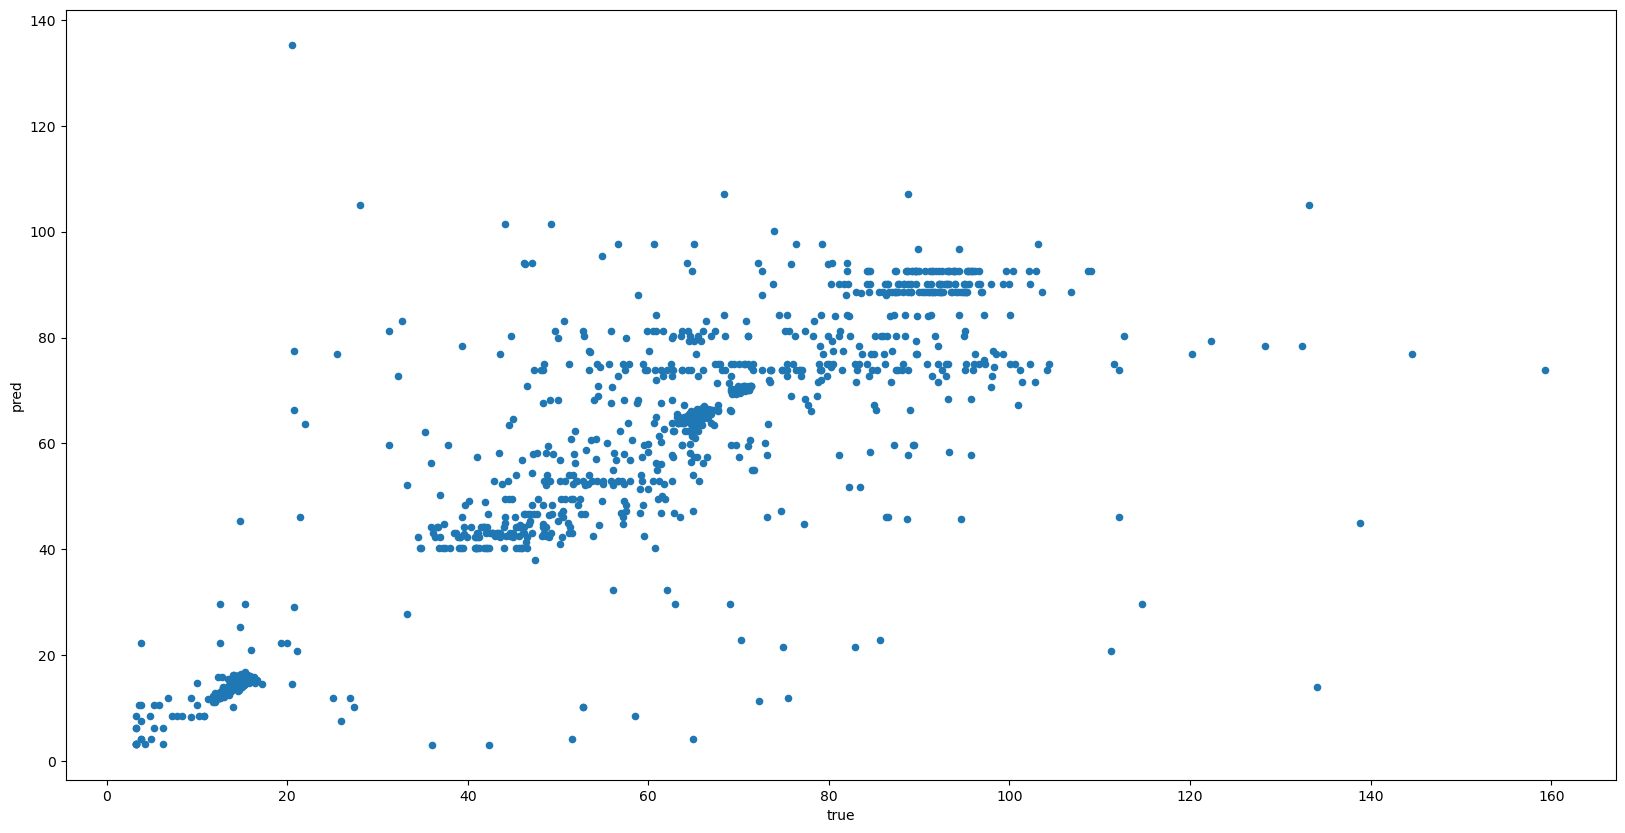

In [416]:
data = {"pred":y_pred,"true":y_test}
results = pd.DataFrame(data)

results.plot(kind="scatter",x="true", y = "pred", figsize = (20,10))
plt.show()

## Overfit

2
5
8
10
15
20
30
50
70
100
150


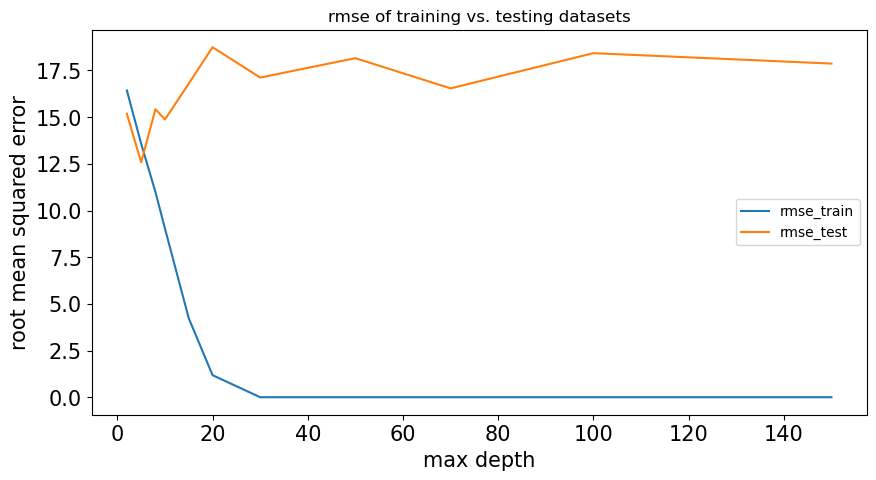

In [427]:
X_train_overfit = X_train
y_train_overfit = y_train

X_test_overfit = X_test
y_test_overfit = y_test
rmse_scores = {'max_depth':[] ,'rmse_train':[], 'rmse_test':[]}

for md in [2, 5, 8, 10, 15, 20, 30, 50, 70, 100, 150]:
    print(md)
    decision_tree_overfit = DecisionTreeRegressor(max_depth=md)
    decision_tree_overfit.fit(X_train_overfit, y_train_overfit)
    
    model_at_hand_overfit = decision_tree_overfit
    
    y_pred_train = model_at_hand_overfit.predict(X_train_overfit)
    rmse_train = sqrt(mean_squared_error(y_train_overfit, y_pred_train))
    
    y_pred_test = model_at_hand_overfit.predict(X_test_overfit)
    rmse_test = sqrt(mean_squared_error(y_test_overfit, y_pred_test))
    
    rmse_scores['max_depth'].append(md)
    rmse_scores['rmse_train'].append(rmse_train)
    rmse_scores['rmse_test'].append(rmse_test)
ax = pd.DataFrame.from_dict(rmse_scores).plot(figsize=(10,5),title="rmse of training vs. testing datasets", fontsize=15, x='max_depth')
ax.set_xlabel("max depth", fontsize=15)
ax.set_ylabel("root mean squared error", fontsize=15)
plt.show()